# 学会正确测量

## 一、理解性能指标

**TTFT：** Time To First Token，从请求开始到第一个输出 token。

它通常包括：
- 排队；
- tokenization；
- Prefill；
- 调度；
- 第一次采样和返回。

**TPOT：** Time Per Output Token，首 token 之后，每个输出 token 的平均时间。
```text
TPOT ≈ (总时间 - TTFT) / (输出token数 - 1)
```

**ITL：** Inter-Token Latency，相邻 token 返回之间的延迟。TPOT 是平均值，ITL 可以形成分布。

**Throughput** 至少区分：
- request throughput：requests/s
- input token throughput：input tokens/s
- output token throughput：output tokens/s

**Latency Percentiles：** 
- P50：典型体验；
- P95/P99：尾部体验；
- 平均数不能反映少量严重卡顿。

## 二、写可靠的 Benchmark Harness

性能测试必须处理：
- warmup；
- GPU异步执行；
- 固定输入；
- 重复测量；
- 均值、中位数和分位数；
- 实验环境记录。

### 1. 实验环境元数据记录 (Environment Tracker)

In [3]:
import gc
import json
import platform
import time
from dataclasses import asdict
from typing import Any, Dict, List

import numpy as np
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

def get_env_metadata(model_name: str, dtype: str) -> Dict[str, Any]:
    """记录实验的硬件与软件环境"""
    return {
        "device_name": (
            torch.cuda.get_device_name(0)
            if torch.cuda.is_available()
            else "CPU"
        ),
        "cuda_version": torch.version.cuda,
        "pytorch_version": torch.__version__,
        "python_version": platform.python_version,
        "os_platform": platform.platform(),
        "model_name": model_name,
        "dtype": str(dtype),
    }

get_env_metadata("test_model", "test_dtype")

{'device_name': 'NVIDIA GeForce RTX 5060 Ti',
 'cuda_version': '12.8',
 'pytorch_version': '2.11.0+cu128',
 'python_version': <function platform.python_version()>,
 'os_platform': 'Linux-6.18.33.2-microsoft-standard-WSL2-x86_64-with-glibc2.43',
 'model_name': 'test_model',
 'dtype': 'test_dtype'}

### 2. 精确的高精度计时器（CUDA Synchronized Timer）

In [4]:
class CUDATimer:
    """包装了 torch.cuda.synchronize 的高精度 CPU-GPU 同步计时器"""

    def __enter__(self):
        if torch.cuda.is_available():
            torch.cuda.synchronize()  # 确保此前所有的 GPU 任务已经完成
        self.start = time.perf_counter()
        return self

    def __exit__(self, *args):
        if torch.cuda.is_available():
            torch.cuda.synchronize()  # 确保刚才下发的 GPU 算子真正执行完毕
        self.end = time.perf_counter()
        self.elapsed_ms = (self.end - self.start) * 1000.0  # 毫秒（ms）

### 3. 数据统计辅助函数 (Statistical Aggregator)

In [6]:
def calculate_stats(data_list: List[float]) -> Dict[str, float]:
    """计算原始测量数据的均值、中位数与分位数"""
    arr = np.array(data_list)
    return {
        "mean": float(np.mean(arr)),
        "std": float(np.std(arr)),
        "median": float(np.median(arr)),
        "p50": float(np.percentile(arr, 50)),
        "p95": float(np.percentile(arr, 95)),
        "p99": float(np.percentile(arr, 99)),
        "min": float(np.min(arr)),
        "max": float(np.max(arr)),
    }

### 4. 核心 Benchmark Runner

In [14]:
def run_benchmark(
        model: torch.nn.Module,
        input_ids: torch.Tensor,
        max_new_tokens: int = 256,
        use_cache: bool = True,
        warmup_runs: int = 3,
        benchmark_runs: int = 10,
) -> Dict[str, Any]:
    """单配置项下的完整测量逻辑：包含 Warmup、重复测量、显存追踪与数据汇总"""
    model.eval()
    eos_token_id = getattr(model.config, "eos_token_id", None)
    if isinstance(eos_token_id, list):
        eos_token_ids = set(eos_token_id)
    else:
        eos_token_ids = {eos_token_id} if eos_token_id is not None else set()

    # -------------------------------------------------------------------------
    # 步骤 A：Warmup（热身阶段）
    # 目的：触发 CUDA Context 初始化、缓存分配器预分配、以及算子 JIT 编译
    # -------------------------------------------------------------------------
    print(f"🔥 开始 Warmup ({warmup_runs} 次)...")
    with torch.inference_mode():
        for _ in range(warmup_runs):
            curr_ids = input_ids.clone()
            past_key_values = None
            for step in range(max_new_tokens):
                inp = curr_ids if (not use_cache or past_key_values is None) else curr_ids[:, -1:]
                outputs = model(inp, past_key_values=past_key_values, use_cache=use_cache)
                if use_cache:
                    past_key_values = outputs.past_key_values
                next_token = outputs.logits[:, -1, :].argmax(dim=-1, keepdim=True)
                curr_ids = torch.cat([curr_ids, next_token], dim=-1)
                if next_token.item() in eos_token_ids:
                    break


    # -------------------------------------------------------------------------
    # 步骤 B：正式测试阶段（Benchmark Runs）
    # -------------------------------------------------------------------------
    raw_ttft_list = []
    raw_total_time_list = []
    raw_tpot_list = []
    generated_tokens_count = 0

    print(f"⏱️ 开始正式 Benchmark 测量 ({benchmark_runs} 次)...")

    # 重置 Peak Memory 统计起点
    if torch.cuda.is_available():
        gc.collect()  # 强制清理掉所有悬空死掉的对象
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    with torch.inference_mode():
        for run_idx in range(benchmark_runs):
            curr_ids = input_ids.clone()
            past_key_values = None
            generated_tokens_count = 0

            # 测量全过程总耗时起点
            with CUDATimer() as total_timer:

                # 1. Prefill 阶段（首 Token）
                with CUDATimer() as prefill_timer:
                    outputs = model(input_ids=curr_ids, past_key_values=None, use_cache=use_cache)
                    next_token = outputs.logits[:, -1, :].argmax(dim=-1, keepdim=True)

                ttft_ms = prefill_timer.elapsed_ms
                if use_cache:
                    past_key_values = outputs.past_key_values

                curr_ids = torch.cat([curr_ids, next_token], dim=-1)
                generated_tokens_count += 1

                # 2. Decode 阶段 (剩余 token)
                for _ in range(max_new_tokens - 1):
                    if next_token.item() in eos_token_ids:
                        break

                    inp = curr_ids[:, -1:] if use_cache else curr_ids
                    outputs = model(input_ids=inp, past_key_values=past_key_values, use_cache=use_cache)

                    if use_cache:
                        past_key_values = outputs.past_key_values

                    next_token = outputs.logits[:, -1, :].argmax(dim=-1, keepdim=True)
                    curr_ids = torch.cat([curr_ids, next_token], dim=-1)
                    generated_tokens_count += 1

            total_ms = total_timer.elapsed_ms

            # 计算 TPOT
            tpot_ms = (total_ms - ttft_ms) / (generated_tokens_count - 1) if generated_tokens_count > 1 else 0.0

            # 记录原始数据
            raw_ttft_list.append(ttft_ms)
            raw_total_time_list.append(total_ms)
            raw_tpot_list.append(tpot_ms)

    # 抓峰值显存（MB）
    peak_memory_mb = torch.cuda.max_memory_allocated() / (1024 * 1024) if torch.cuda.is_available() else 0.0

    # -------------------------------------------------------------------------
    # 步骤 C：汇总并返回完整的实验结果结构
    # -------------------------------------------------------------------------

    return {
        "prompt_length": input_ids.shape[-1],
        "requested_max_new_tokens": max_new_tokens,
        "actual_generated_tokens": generated_tokens_count,
        "use_cache": use_cache,
        "peak_memory_mb": peak_memory_mb,
        "metrics_stats": {
            "ttft_ms": calculate_stats(raw_ttft_list),
            "total_time_ms": calculate_stats(raw_total_time_list),
            "tpot_ms": calculate_stats(raw_tpot_list),
        },
        "raw_data": { # 必须保留原始数据
            "ttft_ms": raw_ttft_list,
            "total_time_ms": raw_total_time_list,
            "tpot_ms": raw_tpot_list,
        },
    }


### 5.正式运行

In [16]:
from pathlib import Path

model_path = Path("../../models/Qwen2.5-1.5B-Instruct/")
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForCausalLM.from_pretrained(model_path, torch_dtype=torch.bfloat16, device_map="cuda")

prompt = "请用一段话介绍一下什么是 AI Infra"
encoded = tokenizer.encode(prompt, return_tensors="pt").to("cuda")


result = run_benchmark(model=model, input_ids=encoded)

print(result)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

🔥 开始 Warmup (3 次)...
⏱️ 开始正式 Benchmark 测量 (10 次)...
{'prompt_length': 9, 'requested_max_new_tokens': 256, 'actual_generated_tokens': 256, 'use_cache': True, 'peak_memory_mb': 5912.212890625, 'metrics_stats': {'ttft_ms': {'mean': 16.139911801292328, 'std': 0.8018517835279472, 'median': 16.045950002080644, 'p50': 16.045950002080644, 'p95': 17.433070450897503, 'p99': 17.561014090570097, 'min': 14.995200002886122, 'max': 17.593000000488246}, 'total_time_ms': {'mean': 4086.529424699984, 'std': 25.857989572094898, 'median': 4091.6411684993363, 'p50': 4091.6411684993363, 'p95': 4121.229635750024, 'p99': 4130.52817114989, 'min': 4045.6858260004083, 'max': 4132.852804999857}, 'tpot_ms': {'mean': 15.962311815288984, 'std': 0.10093681982390655, 'median': 15.98621007253635, 'p50': 15.98621007253635, 'p95': 16.09736460058105, 'p99': 16.135975169520524, 'min': 15.80084245490748, 'max': 16.145627811755393}}, 'raw_data': {'ttft_ms': [16.531404999113875, 16.470999999000924, 14.995200002886122, 15.32000

## 三、实验 -- KV Cache 的时间收益

变量：

```text
prompt length：32、128、512、1024
output length：固定64
batch size：1
use_cache：False / True
```

记录：
- TTFT；
- 总生成时间；
- 平均 decode 时间；
- 峰值显存；
- 输出是否完全一致。

预期现象：
- KV Cache 对 TTFT 帮助不一定明显；
- 输出越长，KV Cache 的累计收益通常越明显；
- KV Cache 会增加持续显存占用；
- 无缓存版本每一步都会重复处理完整历史。

输出两张图：
1. prompt length → 总时间；
2. prompt length → 峰值显存。

### 1. 构造指定 Token 长度的函数

In [20]:
def create_fixed_length_prompt(tokenizer, target_length: int, device="cuda") -> torch.Tensor:
    """生成绝对精度长度为 target_length 的 input_ids 张量 [1, target_length]"""
    base_text = "人工智能与大语言模型正在深度改变人类社会的各个领域，包括软件工程、自动化系统和数据分析。"
    base_ids = tokenizer.encode(base_text, add_special_tokens=False)

    # 通过重复基础 Token 来凑够长度
    repeated_ids = (base_ids * (target_length // len(base_ids) + 1))[:target_length]

    input_ids = torch.tensor([repeated_ids], dtype=torch.long).to(device)

    assert input_ids.shape[-1] == target_length, f"期望长度 {target_length}, 实际生成 {input_ids.shape[-1]}"

    return input_ids

### 2. 开始实验

In [21]:
import pandas as pd

model.eval()

# 实验变量配置
prompt_lengths = [32, 128, 512, 1024]
output_length = 64
warmup_runs = 2
benchmark_runs = 5

results = []

for p_len in prompt_lengths:
    print(f"\n======================== 正在测试 Prompt 长度：{p_len} =========================")
    input_ids = create_fixed_length_prompt(tokenizer=tokenizer, target_length=p_len, device="cuda")

    # ----- 1. 运行无 Cache 版本 -----
    print("运行无 Cache 版本")
    res_no_cache = run_benchmark(model, input_ids, output_length, False, warmup_runs, benchmark_runs)

    # ----- 2. 运行有 Cache 版本 -----
    print("运行有 Cache 版本")
    res_with_cache = run_benchmark(model, input_ids, output_length, True, warmup_runs, benchmark_runs)

    # ----- 3. 对齐校验：抓取单次生成的 Token IDs 进行严格匹配 -----
    with torch.inference_mode():
        # 无 Cache 生成
        curr_ids = input_ids.clone()
        for _ in range(output_length):
            out = model(input_ids=curr_ids, use_cache=False)
            nxt = out.logits[:, -1, :].argmax(dim=-1, keepdim=True)
            curr_ids = torch.cat([curr_ids, nxt], dim=-1)
        tokens_no_cache = curr_ids[0, p_len:].tolist()

        # 有 Cache 生成
        curr_ids = input_ids.clone()
        past_kv = None
        for step in range(output_length):
            inp = curr_ids if past_kv is None else curr_ids[:, -1:]
            out = model(input_ids=inp, past_key_values=past_kv, use_cache=True)
            past_kv = out.past_key_values
            nxt = out.logits[:, -1, :].argmax(dim=-1, keepdim=True)
            curr_ids = torch.cat([curr_ids, nxt], dim=-1)
        tokens_with_cache = curr_ids[0, p_len:].tolist()

    tokens_match = tokens_no_cache == tokens_with_cache
    print(f" 🔍 Token 对齐检查: {'✅ 完全一致' if tokens_match else '❌ 不一致'}")

    # 记录数据
    for use_cache, res_data in [(False, res_no_cache), (True, res_with_cache)]:
        results.append(
            {
                "prompt_length": p_len,
                "use_cache": use_cache,
                "ttft_ms": res_data["metrics_stats"]["ttft_ms"]["mean"],
                "total_time_ms": res_data["metrics_stats"]["total_time_ms"][
                    "mean"
                ],
                "avg_decode_time_ms": res_data["metrics_stats"]["tpot_ms"][
                    "mean"
                ],
                "peak_memory_mb": res_data["peak_memory_mb"],
                "tokens_match": tokens_match,
            }
        )

# 转换为 DataFrame 汇总展现
df_results = pd.DataFrame(results)
print("\n======================== 实验数据汇总表格 =========================")
print(df_results.to_string(index=False))


======================== 正在测试 Prompt 长度：32 =========================
运行无 Cache 版本
🔥 开始 Warmup (2 次)...
⏱️ 开始正式 Benchmark 测量 (5 次)...
运行有 Cache 版本
🔥 开始 Warmup (2 次)...
⏱️ 开始正式 Benchmark 测量 (5 次)...
 🔍 Token 对齐检查: ✅ 完全一致

======================== 正在测试 Prompt 长度：128 =========================
运行无 Cache 版本
🔥 开始 Warmup (2 次)...
⏱️ 开始正式 Benchmark 测量 (5 次)...
运行有 Cache 版本
🔥 开始 Warmup (2 次)...
⏱️ 开始正式 Benchmark 测量 (5 次)...
 🔍 Token 对齐检查: ✅ 完全一致

======================== 正在测试 Prompt 长度：512 =========================
运行无 Cache 版本
🔥 开始 Warmup (2 次)...
⏱️ 开始正式 Benchmark 测量 (5 次)...
运行有 Cache 版本
🔥 开始 Warmup (2 次)...
⏱️ 开始正式 Benchmark 测量 (5 次)...
 🔍 Token 对齐检查: ✅ 完全一致

======================== 正在测试 Prompt 长度：1024 =========================
运行无 Cache 版本
🔥 开始 Warmup (2 次)...
⏱️ 开始正式 Benchmark 测量 (5 次)...
运行有 Cache 版本
🔥 开始 Warmup (2 次)...
⏱️ 开始正式 Benchmark 测量 (5 次)...
 🔍 Token 对齐检查: ✅ 完全一致

======================== 实验数据汇总表格 =========================
 prompt_length  use_cache    ttft_ms  total_time_ms  av

### 3. 数据可视化

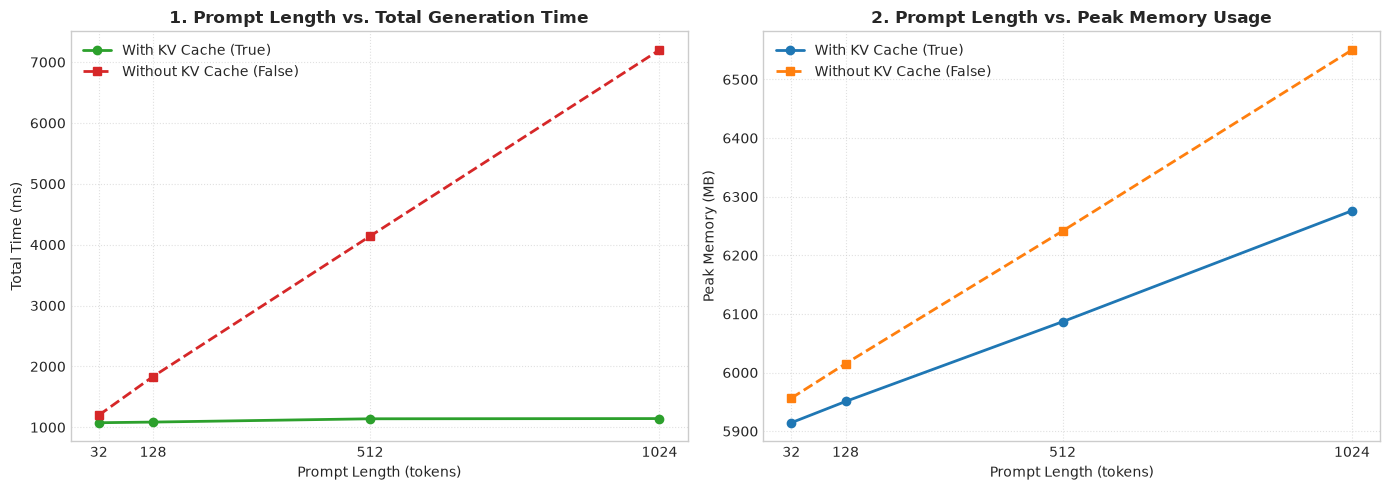

In [22]:
import matplotlib.pyplot as plt

# 设置绘图样式
plt.figure(figsize=(14, 5))
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

# -------------------------------------------------------------------------
# 图 1：Prompt Length → 总耗时 (Total Time)
# -------------------------------------------------------------------------
plt.subplot(1, 2, 1)
df_cache_true = df_results[df_results["use_cache"] == True]
df_cache_false = df_results[df_results["use_cache"] == False]

plt.plot(df_cache_true["prompt_length"], df_cache_true["total_time_ms"], 'o-', label="With KV Cache (True)", color="#2ca02c", linewidth=2)
plt.plot(df_cache_false["prompt_length"], df_cache_false["total_time_ms"], 's--', label="Without KV Cache (False)", color="#d62728", linewidth=2)

plt.title("1. Prompt Length vs. Total Generation Time", fontsize=12, fontweight='bold')
plt.xlabel("Prompt Length (tokens)", fontsize=10)
plt.ylabel("Total Time (ms)", fontsize=10)
plt.xticks(prompt_lengths)
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

# -------------------------------------------------------------------------
# 图 2：Prompt Length → 峰值显存 (Peak Memory)
# -------------------------------------------------------------------------
plt.subplot(1, 2, 2)
plt.plot(df_cache_true["prompt_length"], df_cache_true["peak_memory_mb"], 'o-', label="With KV Cache (True)", color="#1f77b4", linewidth=2)
plt.plot(df_cache_false["prompt_length"], df_cache_false["peak_memory_mb"], 's--', label="Without KV Cache (False)", color="#ff7f0e", linewidth=2)

plt.title("2. Prompt Length vs. Peak Memory Usage", fontsize=12, fontweight='bold')
plt.xlabel("Prompt Length (tokens)", fontsize=10)
plt.ylabel("Peak Memory (MB)", fontsize=10)
plt.xticks(prompt_lengths)
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

In [24]:
print(df_results.to_string(index=False))

 prompt_length  use_cache    ttft_ms  total_time_ms  avg_decode_time_ms  peak_memory_mb  tokens_match
            32      False  18.283779    1198.472159           18.733149     5956.354980          True
            32       True  17.573679    1074.843308           16.782058     5914.435547          True
           128      False  19.551103    1833.863752           28.798613     6015.167969          True
           128       True  20.256227    1085.360887           16.906423     5950.678711          True
           512      False  53.027503    4140.600830           64.882116     6241.487305          True
           512       True  54.430732    1139.472539           17.222886     6086.719727          True
          1024      False 101.218297    7199.646864          112.673469     6550.250977          True
          1024       True 101.315904    1143.015187           16.534909     6275.987305          True


## 四、实验 -- 输入长度与输出长度